In [55]:
import scanpy
import matplotlib
from matplotlib import pyplot
import hdf5plugin
import numpy
import scvelo
import pandas
import warnings
import cellrank
import single_cell_analysis

In [56]:
# Scanpy plotting setup

figure_size = (5, 5)
fontsize = 14
scanpy.set_figure_params(figsize=figure_size, dpi=100, color_map="plasma", frameon=True, fontsize=fontsize)
pyplot.rcParams.update({"axes.grid": False})
pyplot.rcParams["text.usetex"] = True
latex_preamble = r"\usepackage{DejaVuSans} \renewcommand{\familydefault}{\sfdefault} \usepackage{sansmath} \sansmath"
pyplot.rcParams["text.latex.preamble"] = latex_preamble

# Suppress warnings
warnings.simplefilter("ignore", category=UserWarning)
warnings.simplefilter("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=matplotlib.MatplotlibDeprecationWarning)

In [68]:
# Read input file

working_directory = "Data/"

# Use adata from velocity analysis
adata = scanpy.read_h5ad(working_directory + "/clustered_anndata.h5ad")

print(adata)

AnnData object with n_obs × n_vars = 16146 × 2104
    obs: 'leiden_0.6', 'leiden_0.2_c6', 'sample', 'latent_time'
    var: 'gene_ids', 'fit_likelihood'
    uns: 'leiden_0.2_c6_colors', 'leiden_0.6_colors', 'neighbors', 'sample_colors'
    obsm: 'X_umap'
    varm: 'PCs', 'loss'
    layers: 'Ms', 'Mu', 'ambiguous', 'fit_t', 'fit_tau', 'fit_tau_', 'matrix', 'spliced', 'unspliced', 'velocity', 'velocity_u'
    obsp: 'connectivities', 'distances'


In [69]:
# Change cluster names and colors

cluster_name_map = {
    '0': "1",
    '1': "2",
    '2': "3",
    '3': "4",
    '4': "5",
    '5': "6",
    '6,0': "7.1",
    '6,1': "7.2",
    '7': "8.1",
    '7.1': "8.2",
    '9': "9",
    '10,0': "10.1",
    '10,1': "10.2",
    '10,2': "10.3",
    '11': "11",
    '12': "12",
    '13': "13",
    '14': "14",
    '15': "15",
    '16': "16.1",
    '16.1': "16.2",
    '17': "17",
    '18': "18",
    '19': "19",
    '20': "20",
    '21': "21",
    '22': "22"
}

cluster_colors = [
    "#187bb1",
    "#6b7dbf",
    "#0b8280",
    "#fdba74",
    "#c24c4c",
    "#9acf84",
    "#fba21d",
    "#fbc01d",
    "#3853a4",
    "#3882a4",
    "#9166ad",
    "#c5b1d5",
    "#b42172",
    "#d485bd",
    "#875648",
    "#c29c93",
    "#dc84b4",
    "#e6a77b",
    "#7c277d",
    "#4db748",
    "#33942e",
    "#bbbe33",
    "#d7d786",
    "#1cc1d3",
    "#777777",
    "#f77851",
    "#4a5873"
]

# Rename and reorder categories
adata.obs["leiden_0.2_c6"] = adata.obs["leiden_0.2_c6"].cat.rename_categories(cluster_name_map).cat.reorder_categories(cluster_name_map.values())

# Rename the cluster category to "cluster"
adata.obs["cluster"] = adata.obs["leiden_0.2_c6"]
adata.obs.drop(columns=["leiden_0.2_c6"], inplace=True)

# Change cluster colors to the ones in the article
adata.uns["cluster_colors"] = cluster_colors

# Rename samples
new_sample_names = [f"Day {old_name[1:]}" for old_name in adata.obs["sample"].cat.categories]
adata.obs["sample"] = adata.obs["sample"].cat.rename_categories(new_sample_names)

# Assign sample colors
adata.uns["sample_colors"] = [
    "#62f54f", 
    "#00ac4d",
    "#209fda",
    "#263ec7",
    "#3A0070",
]

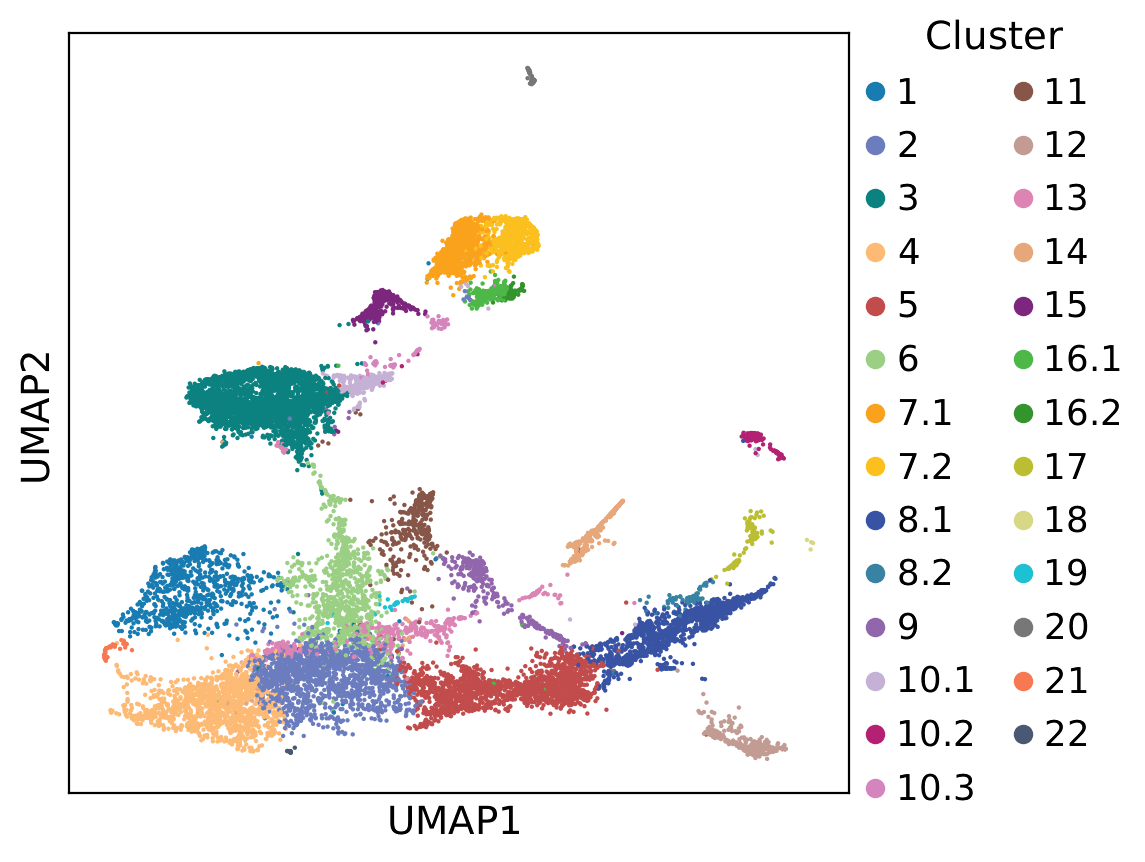

In [71]:
# Plot UMAP

axis = scanpy.pl.embedding(basis='umap', adata=scanpy.pp.subsample(adata, fraction=1, copy=True), color="cluster", size=10, title="", show=False)
legend = axis.get_legend()
legend.set_title("Cluster", {"size": 14})
figure = axis.figure
pyplot.show()
figure.savefig("Graphs/pv_umap.png", dpi=300, bbox_inches="tight")

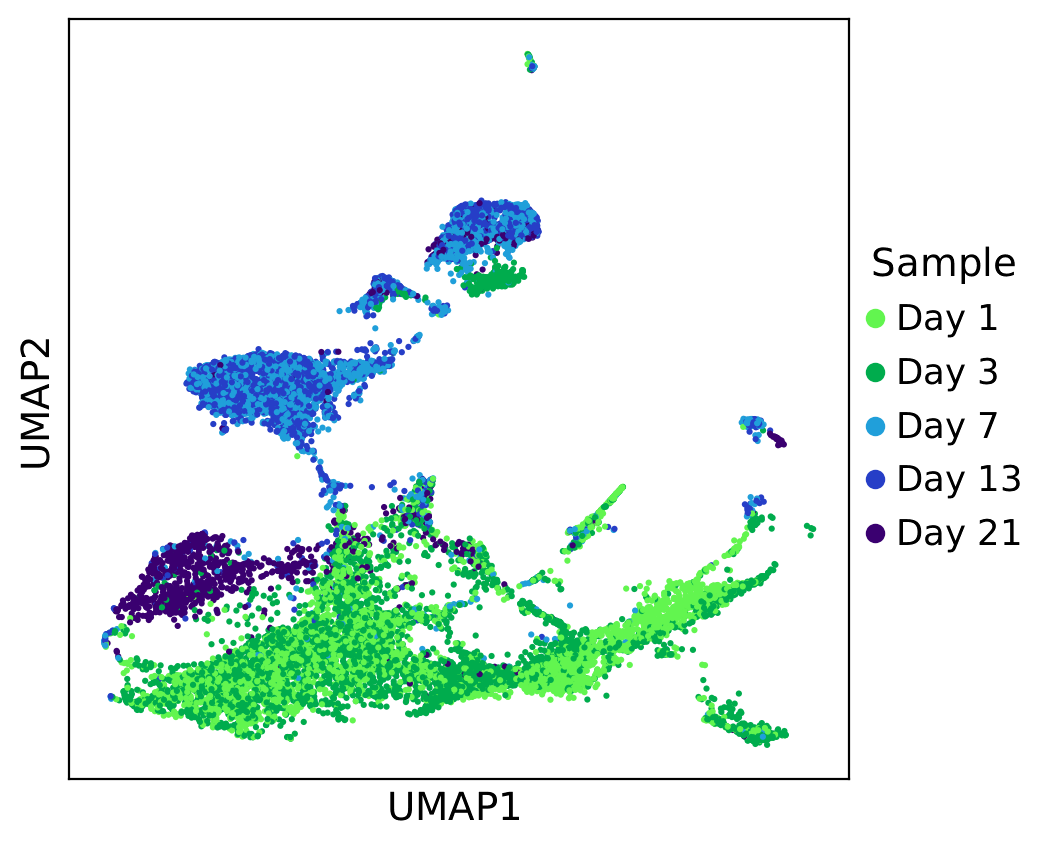

In [70]:
# Plot samples on UMAP

axis = scanpy.pl.embedding(basis='umap', adata=scanpy.pp.subsample(adata, fraction=1, copy=True), color="sample", size=20, title="", show=False, sort_order=False)
legend = axis.get_legend()
legend.set_title("Sample", {"size": 14})
figure = axis.figure
pyplot.show()
figure.savefig("Graphs/pv_umap_sample.png", dpi=300, bbox_inches="tight")

# Plots of velocity and latent time

computing velocity graph (using 16/32 cores)


  0%|          | 0/16146 [00:00<?, ?cells/s]

[0]PETSC ERROR: ------------------------------------------------------------------------
[0]PETSC ERROR: Caught signal number 13 Broken Pipe: Likely while reading or writing to a socket
[0]PETSC ERROR: Try option -start_in_debugger or -on_error_attach_debugger
[0]PETSC ERROR: or see https://petsc.org/release/faq/#valgrind and https://petsc.org/release/faq/
[0]PETSC ERROR: configure using --with-debugging=yes, recompile, link, and run 
[0]PETSC ERROR: to get more information on the crash.
Abort(59) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0


    finished (0:00:12) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:01) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


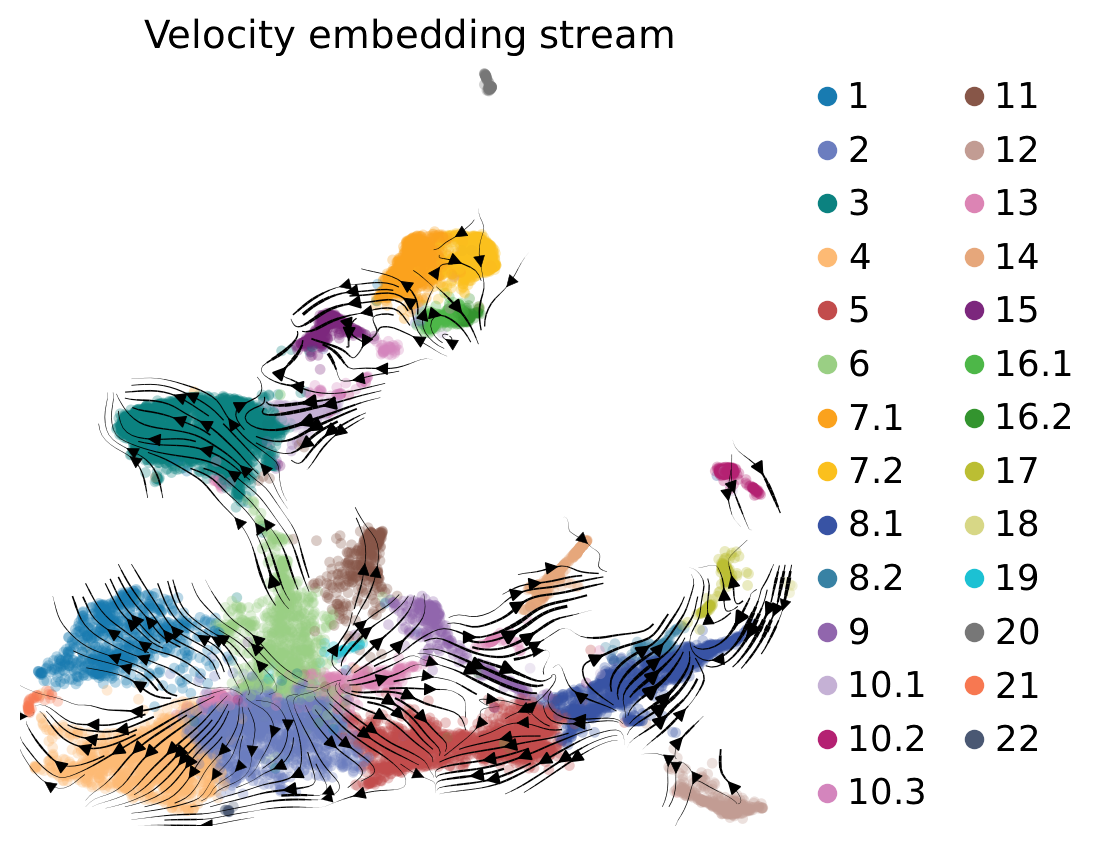

In [33]:
# Velocity on UMAP

scvelo.tl.velocity_graph(adata, vkey="velocity", n_jobs=16)
scvelo.pl.velocity_embedding_stream(adata, vkey="velocity", basis="umap", color="cluster",
                                    legend_loc="right", title="Velocity embedding stream", density=4)

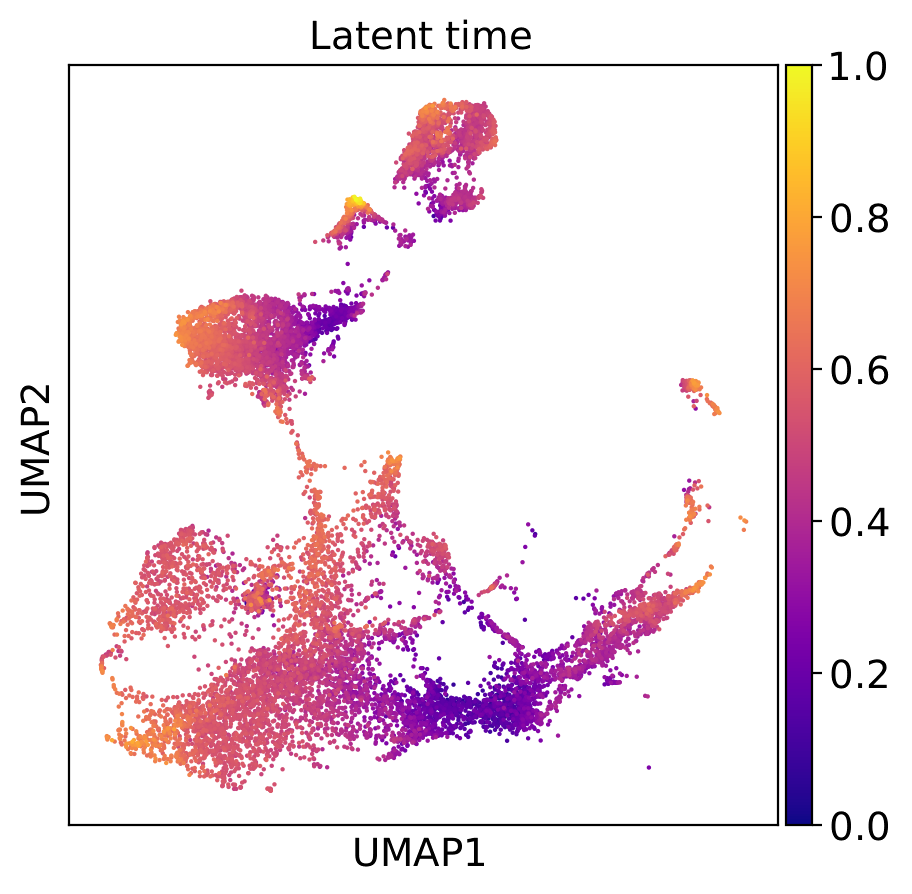

In [83]:
# Latent time on UMAP

axis_list = scanpy.pl.embedding(basis="umap", adata=adata, color="latent_time", size=10, title="Latent time", show=False)
pyplot.show()

# Cellrank analysis

In [73]:
# Exclude the problematic clusters 12, 14 and 20
adata = adata[~((adata.obs["cluster"]=="12") | (adata.obs["cluster"]=="14") | (adata.obs["cluster"]=="20"))]

In [74]:
# Create velocity kernel

velocity_kernel = cellrank.kernels.VelocityKernel(adata, vkey="velocity")
velocity_kernel.compute_transition_matrix()

  0%|          | 0/15406 [00:00<?, ?cell/s]

  0%|          | 0/15406 [00:00<?, ?cell/s]

VelocityKernel[n=15406, model='deterministic', similarity='correlation', softmax_scale=9.463]

In [75]:
# Create kernel based on latent time

latent_time_kernel = cellrank.kernels.PseudotimeKernel(adata, time_key = "latent_time")
latent_time_kernel.compute_transition_matrix()

  0%|          | 0/15406 [00:00<?, ?cell/s]

PseudotimeKernel[n=15406, dnorm=False, scheme='hard', frac_to_keep=0.3]

In [76]:
# Kernel based on gene expression similarity

connectivity_kernel = cellrank.kernels.ConnectivityKernel(adata)
connectivity_kernel.compute_transition_matrix()

ConnectivityKernel[n=15406, dnorm=True, key='connectivities']

In [77]:
# Combine all three kernels

combined_kernel = 0.4*velocity_kernel + 0.4*latent_time_kernel + 0.2*connectivity_kernel
combined_kernel.compute_transition_matrix()

(0.4 * VelocityKernel[n=15406, model='deterministic', similarity='correlation', softmax_scale=9.463] + 0.4 * PseudotimeKernel[n=15406, dnorm=False, scheme='hard', frac_to_keep=0.3] + 0.2 * ConnectivityKernel[n=15406, dnorm=True, key='connectivities'])

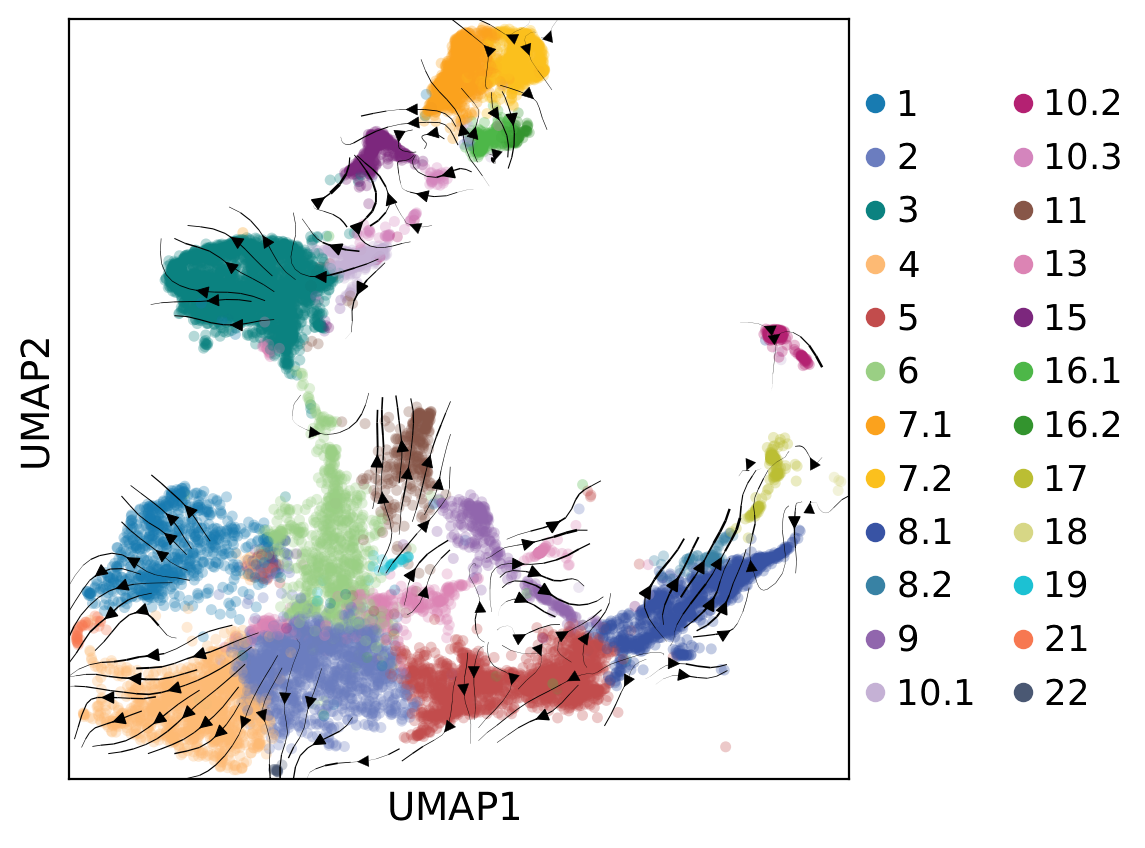

In [42]:
# Plot kernel vector field

combined_kernel.plot_projection(basis="umap", color="cluster", legend_loc="right margin", frameon=True, title="")

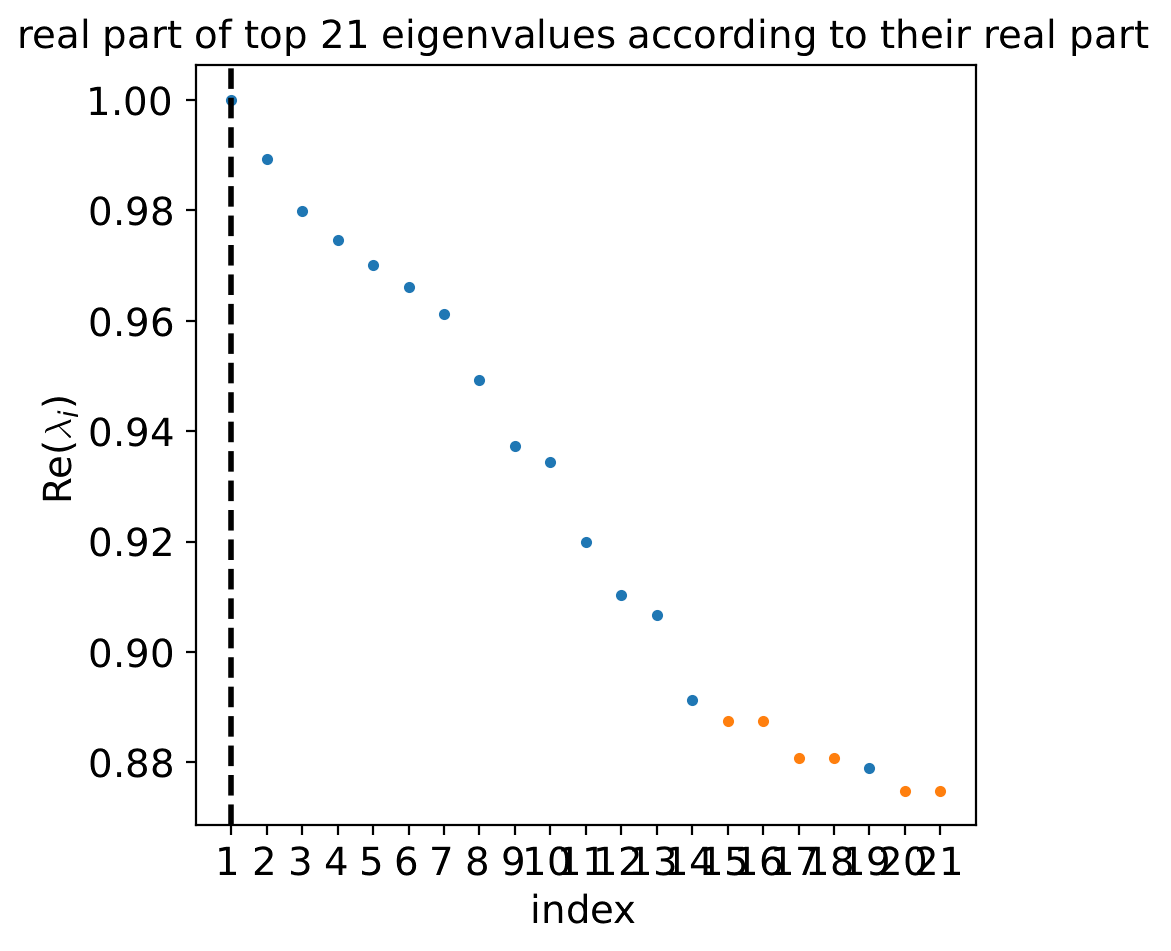

In [78]:
estimator = cellrank.estimators.GPCCA(combined_kernel)
estimator.compute_schur()
estimator.plot_spectrum(real_only=True)

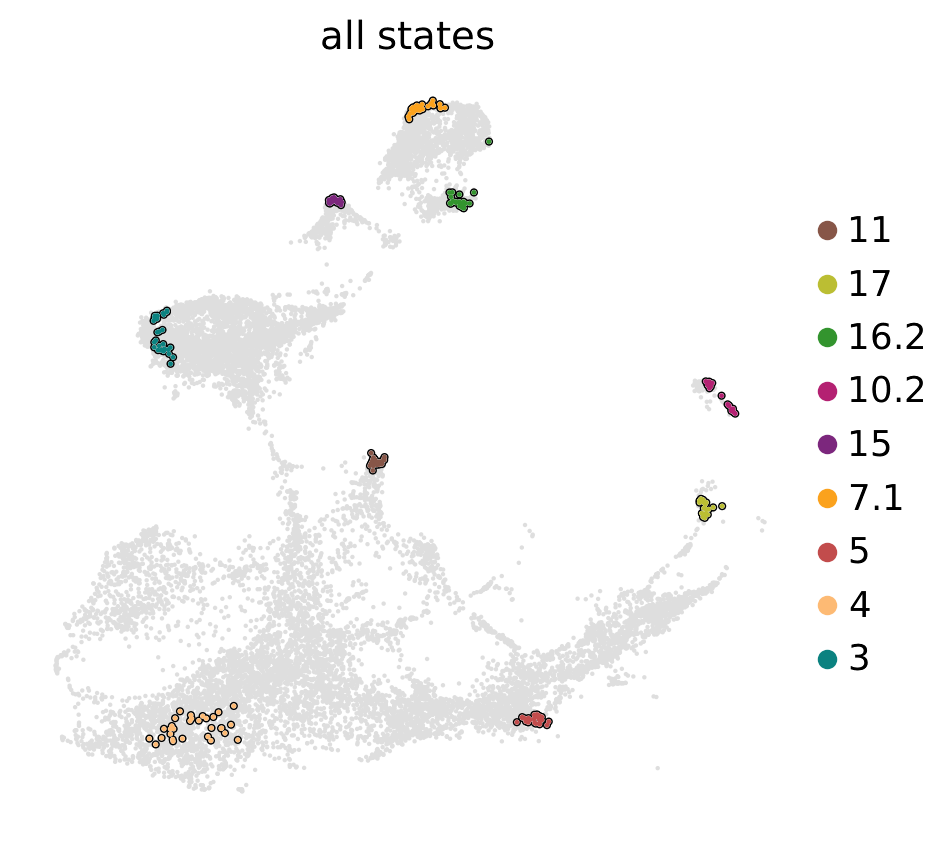

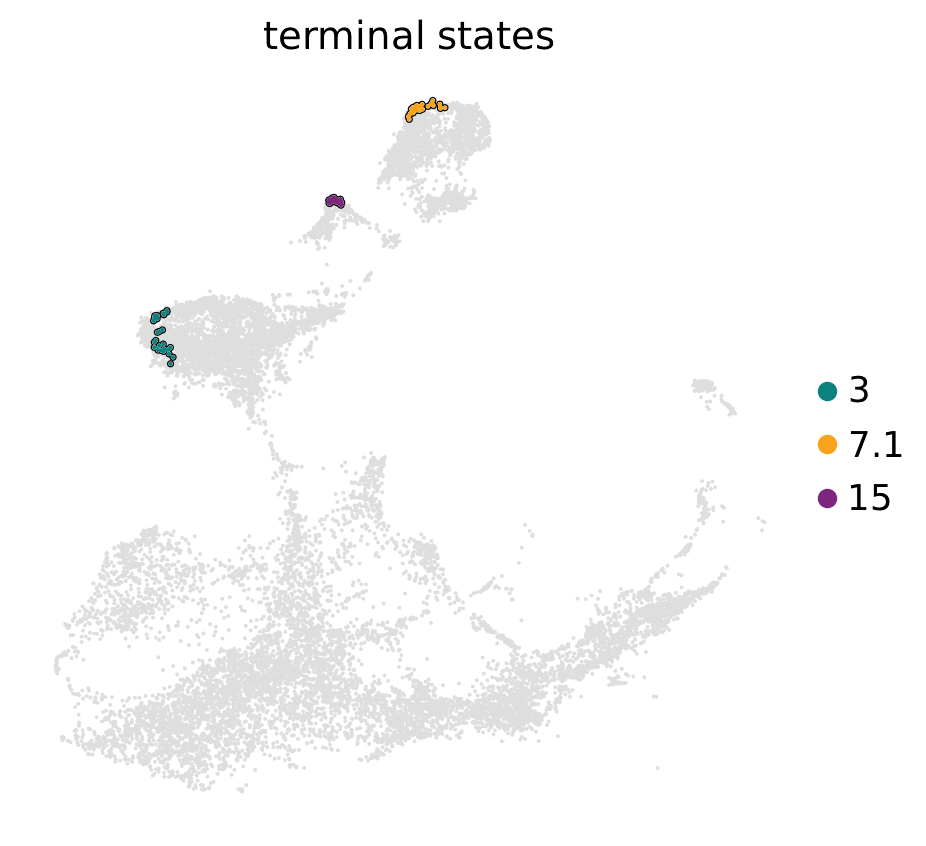

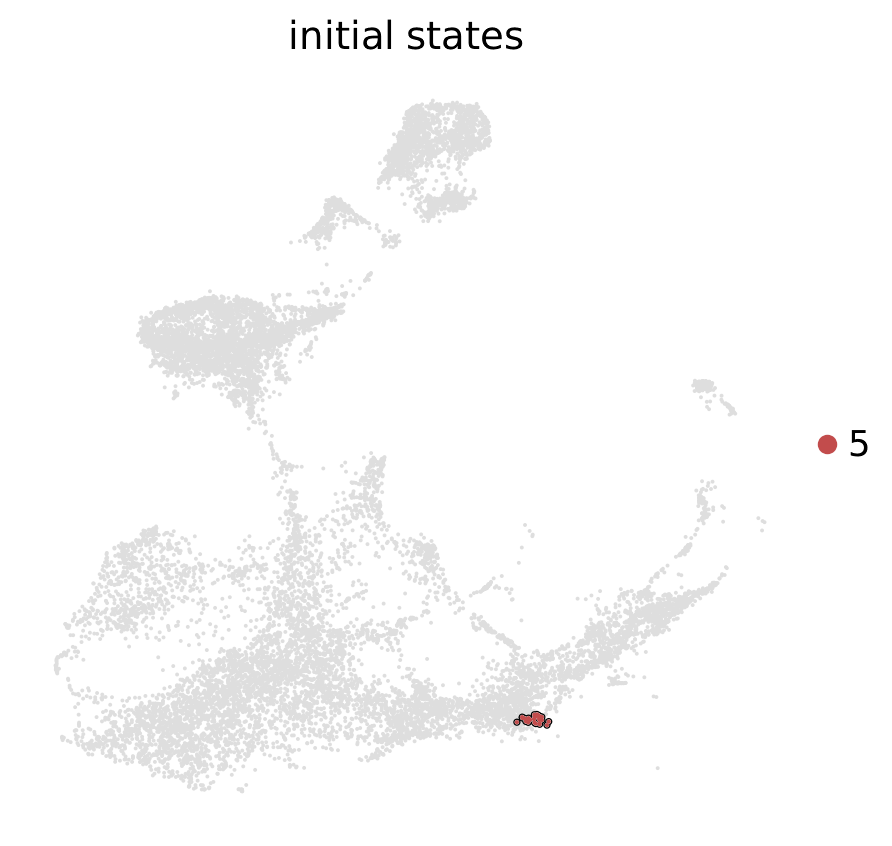

In [79]:
# Find macrostates
estimator.compute_macrostates(n_states=9, cluster_key="cluster")

estimator.plot_macrostates(which="all", legend_loc="right", s=10, basis="umap")
macrostates = estimator.macrostates_memberships.names

# Predict terminal states
estimator.predict_terminal_states(method="top_n", n_states=3)
estimator.plot_macrostates(which="terminal", legend_loc="right", discrete=True, basis="umap")
terminal_states = estimator.terminal_states_memberships.names

# Predict initial states
estimator.predict_initial_states(allow_overlap=True)
estimator.plot_macrostates(which="initial", legend_loc="right", basis="umap", discrete=True)
initial_states = estimator.initial_states_memberships.names

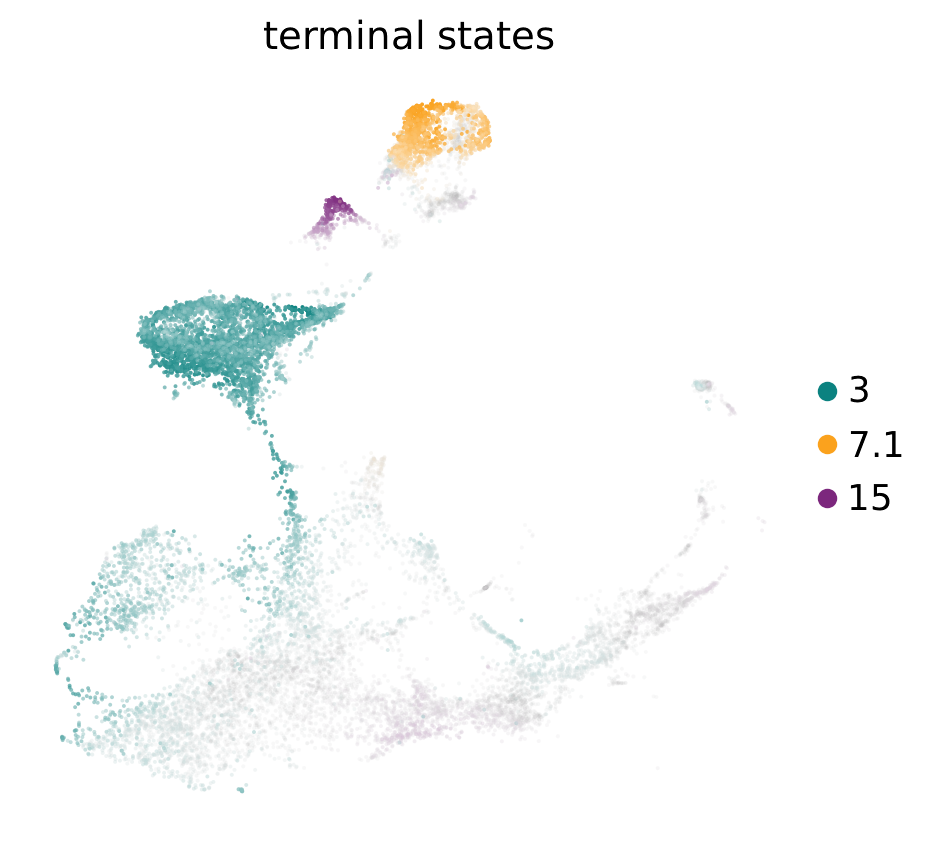

In [80]:
# Plot probability of cells belonging to the terminal states

estimator.plot_macrostates(which="terminal", legend_loc="right", discrete=False, basis="umap")

In [81]:
# Plot stability values. These are used to find terminal states with method="stability"

stability_values = estimator.coarse_T.values.diagonal()

stability_df = pandas.DataFrame({
    "Macrostate": macrostates,
    "Stability": stability_values
}).sort_values("Stability", ascending=False)

print(stability_df)

  Macrostate  Stability
4         15   0.982305
5        7.1   0.980169
8          3   0.977393
3       10.2   0.974253
1         17   0.972101
0         11   0.971549
6          5   0.966095
7          4   0.960101
2       16.2   0.944047


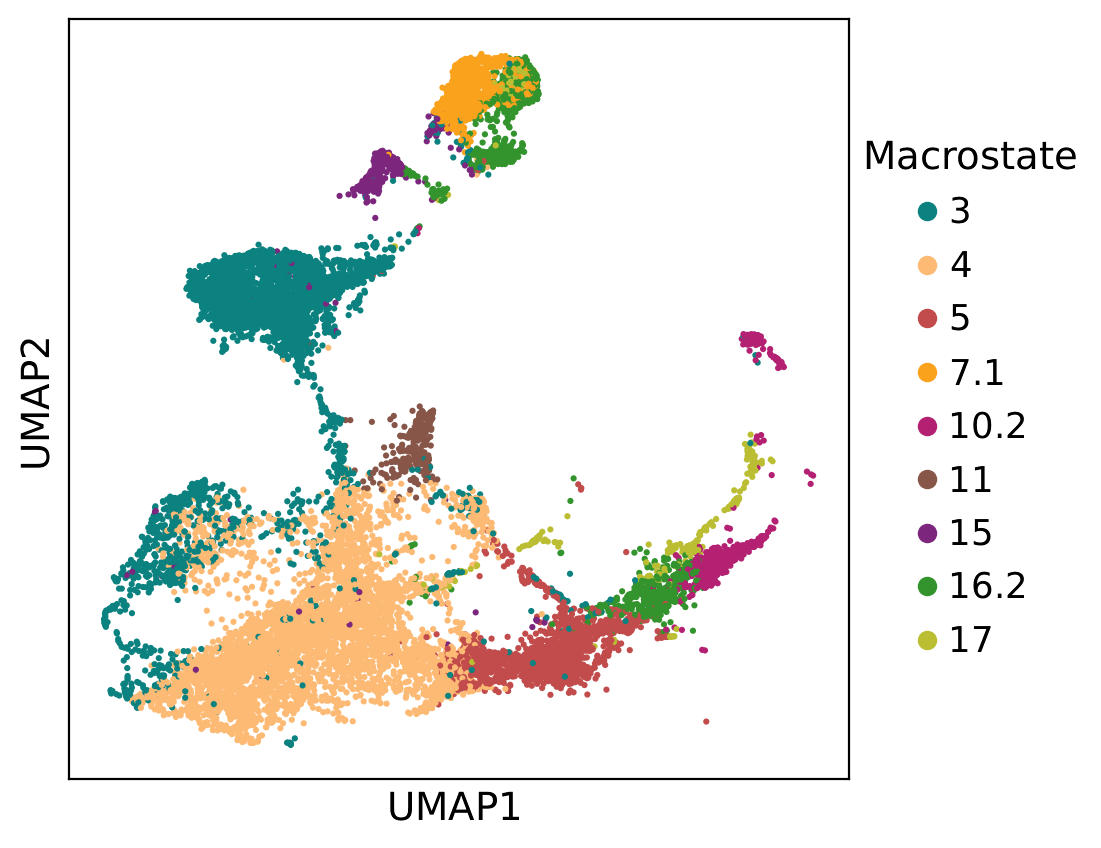

In [87]:
# Assign each cell to the most likely macrostate
macrostates = adata.uns["coarse_fwd"].obs["coarse_init_dist"].index.to_list()
macrostate_assignment = [macrostates[numpy.argmax(macrostate_probabilities.tolist())] for macrostate_probabilities in adata.obsm["macrostates_fwd_memberships"]]
adata.obs["macrostate"] = pandas.Categorical(macrostate_assignment)
sorted_macrostates = sorted(macrostates, key=float)
adata.obs["macrostate"] = adata.obs["macrostate"].cat.reorder_categories(sorted_macrostates)
macrostate_indices = [numpy.argmax(adata.obs["cluster"].cat.categories == cluster) for cluster in sorted_macrostates]
adata.uns["macrostate_colors"] = [adata.uns["cluster_colors"][macrostate_index] for macrostate_index in macrostate_indices]

# Plot macrostates
axis = scanpy.pl.embedding(adata, basis="umap", color="macrostate", title="", show=False, s=20)
legend = axis.get_legend()
legend.set_title("Macrostate", {"size": 14})
figure = axis.figure
pyplot.show()
figure.savefig("Graphs/pv_macrostates.png", dpi=300, bbox_inches="tight")

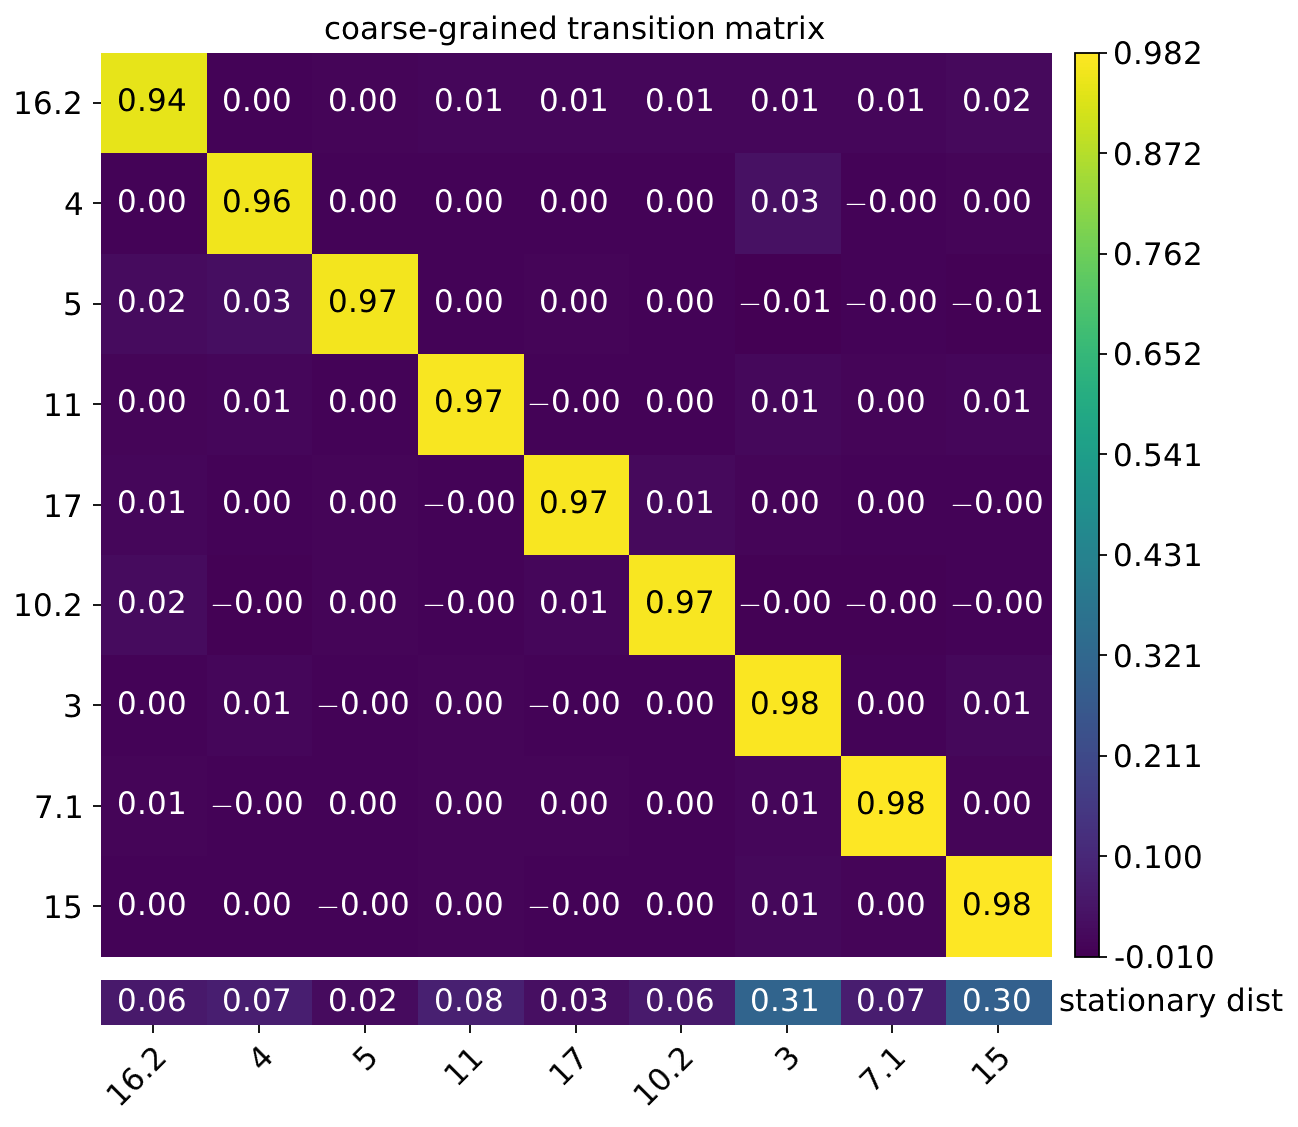

In [83]:
estimator.plot_coarse_T()

  0%|          | 0/3 [00:00<?, ?/s]

  0%|          | 0/3 [00:00<?, ?/s]

[0]PETSC ERROR: ------------------------------------------------------------------------
[0]PETSC ERROR: Caught signal number 13 Broken Pipe: Likely while reading or writing to a socket
[0]PETSC ERROR: Try option -start_in_debugger or -on_error_attach_debugger
[0]PETSC ERROR: or see https://petsc.org/release/faq/#valgrind and https://petsc.org/release/faq/
[0]PETSC ERROR: configure using --with-debugging=yes, recompile, link, and run 
[0]PETSC ERROR: to get more information on the crash.
Abort(59) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0


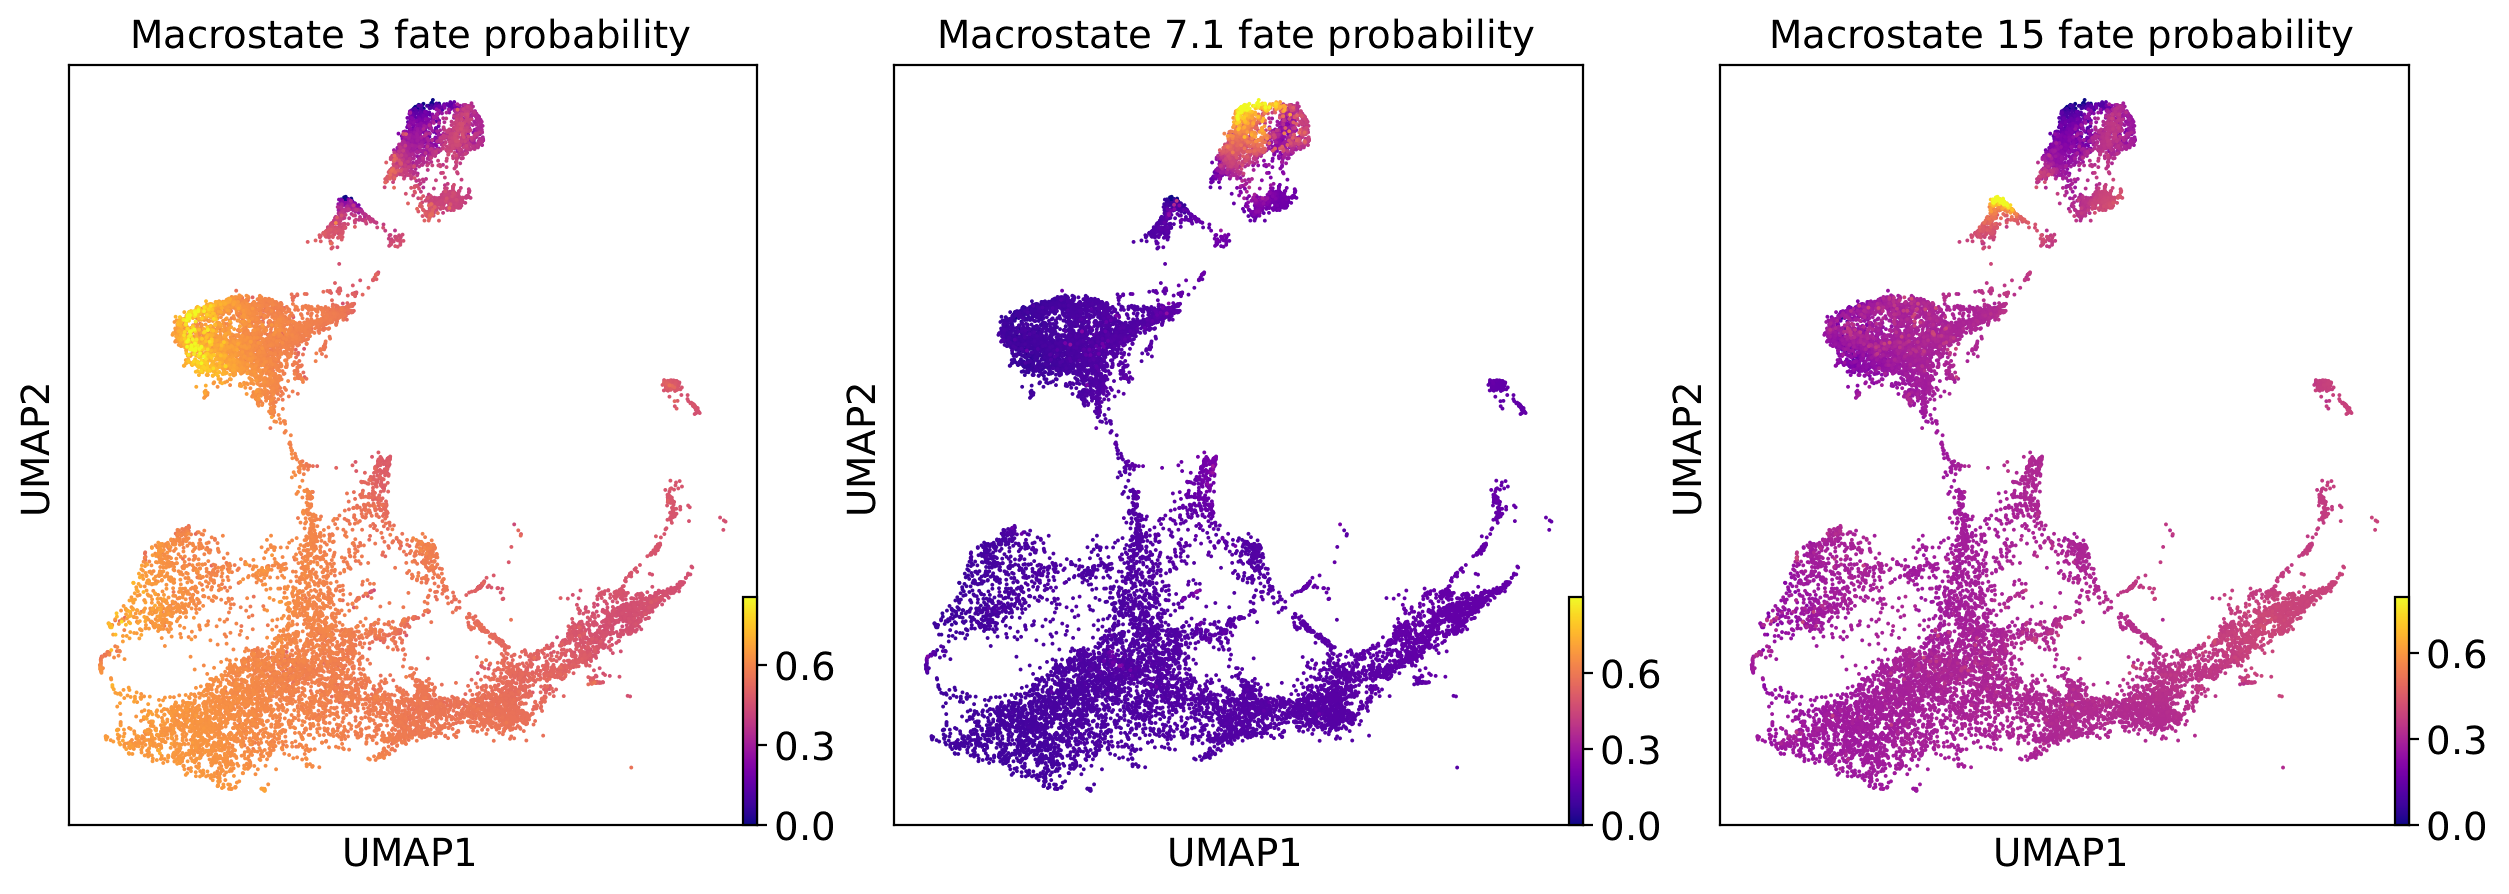

In [84]:
# Estimate fate probabilities

estimator.compute_fate_probabilities()

# Add fate probabilities to adata
for terminal_state in terminal_states:
    adata.obs[f"fate_probabilities_{terminal_state}"] = estimator.fate_probabilities[terminal_state].X.flatten()
estimator.compute_fate_probabilities()
estimator.plot_fate_probabilities(same_plot=False, basis="umap", cmap="plasma",
                                  title=["Macrostate 3 fate probability", "Macrostate 7.1 fate probability", "Macrostate 15 fate probability"],
                                  frameon=True, show=False)
axis = pyplot.gca()
figure = axis.figure
pyplot.show()
figure.savefig("Graphs/pv_fate_probabilities.png", dpi=300, bbox_inches="tight")

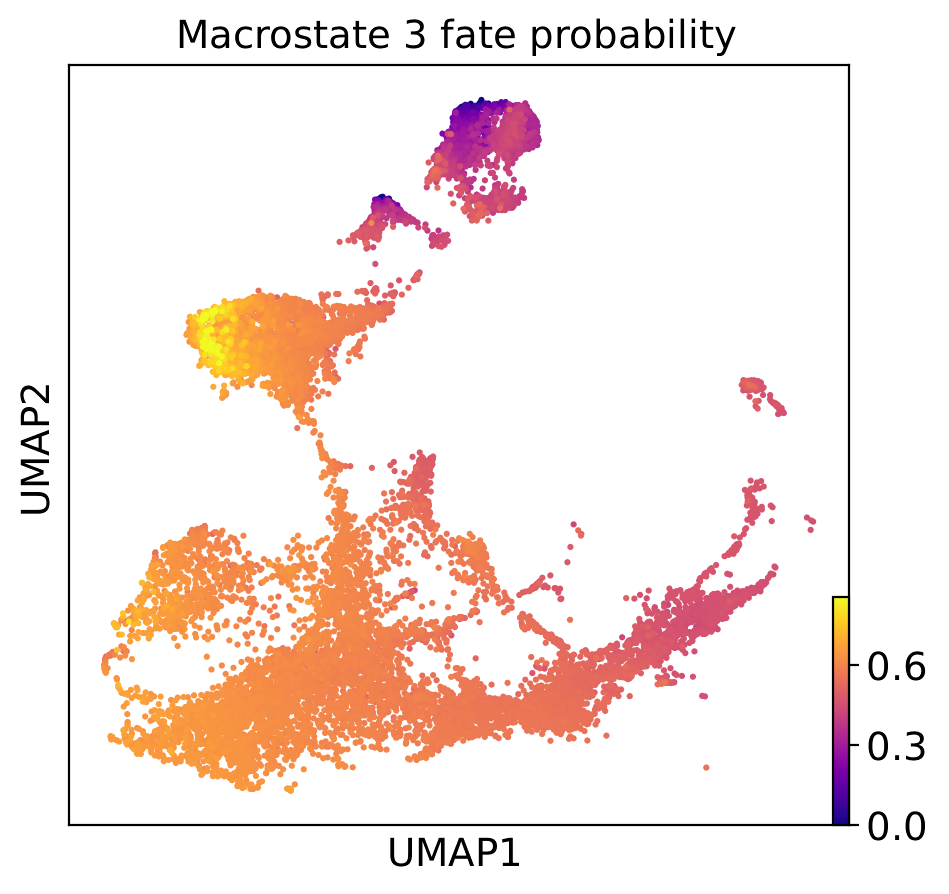

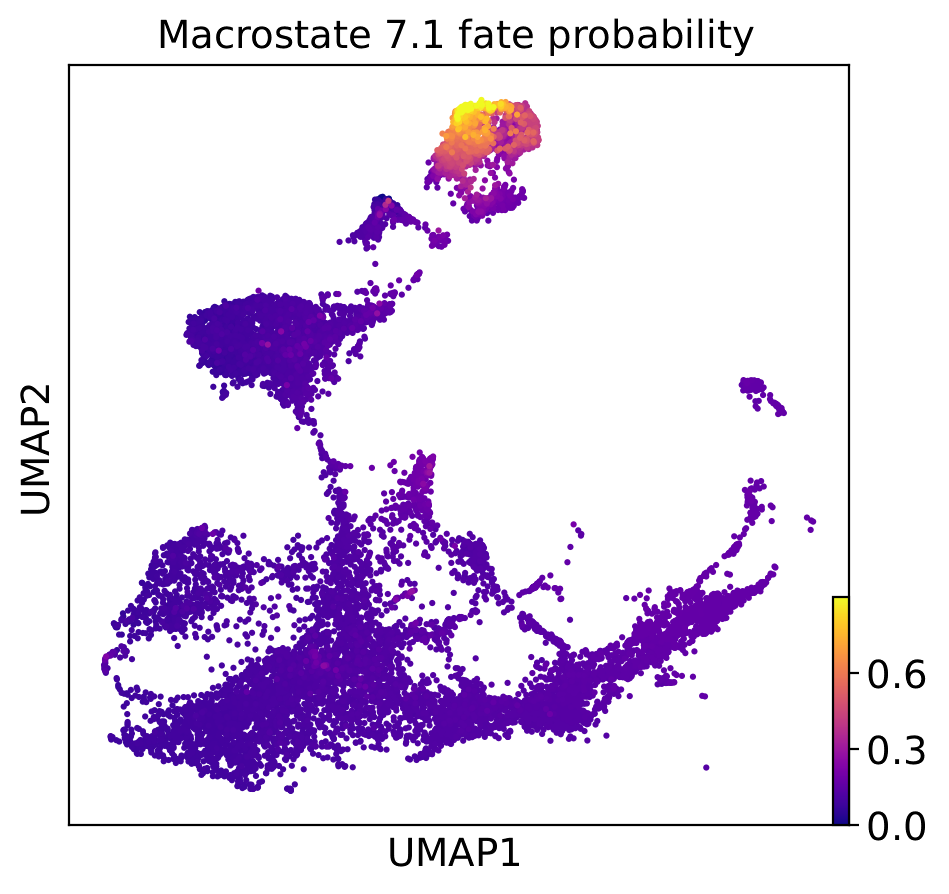

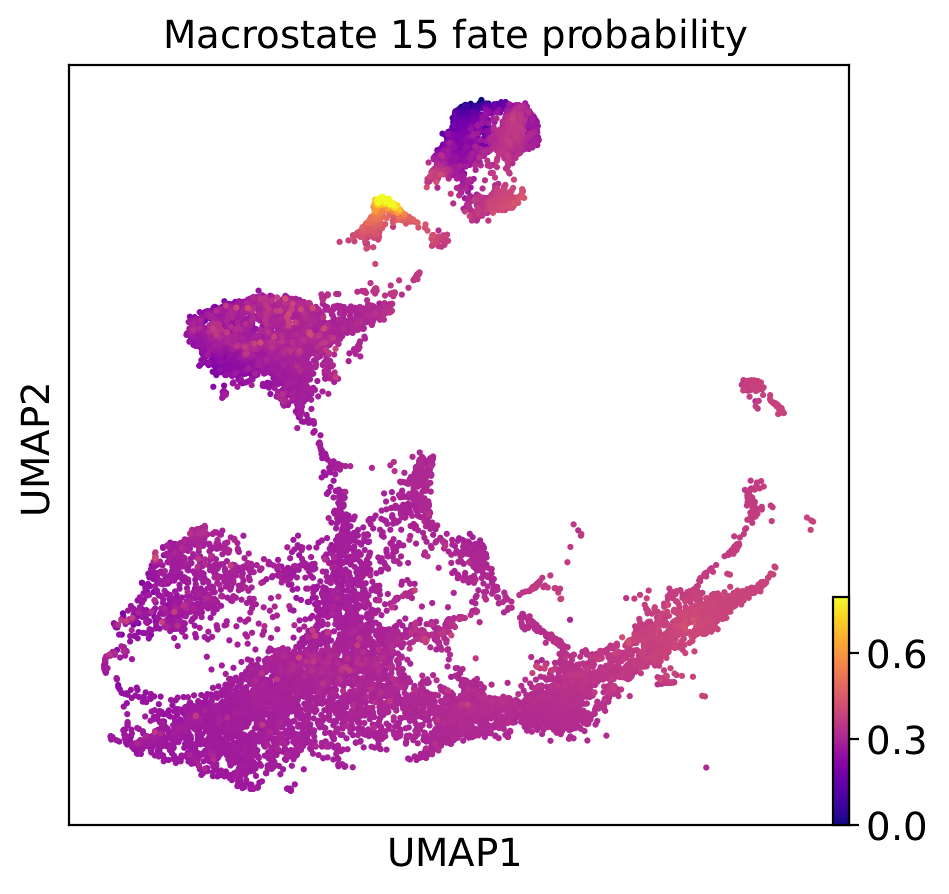

In [86]:
# Plot fate probabilities in separate plots

for terminal_state in terminal_states:
    estimator.plot_fate_probabilities(basis="umap", cmap="plasma", title=f"Macrostate {terminal_state} fate probability", frameon=True, show=False, states=terminal_state,
                                      s=20)
    axis = pyplot.gca()
    figure = axis.figure
    pyplot.show()
    figure.savefig(f"Graphs/pv_fate_probabilities_{terminal_state}.png", dpi=300, bbox_inches="tight")

# Setup for plotting gene trends

In [84]:
# Function for plotting trends independent of trajectory

# Assign cells to the PV or dead end trajectory
pv_trajectory_clusters = ["8.1", "8.2", "16.1", "16.2", "7.1", "7.2", "10.2", "10.3", "15"]
dead_end_trajectory_clusters = ["1", "2", "3", "4", "5", "6"]
trajectory_array = numpy.full(adata.shape[0], None, dtype=object)
trajectory_array[adata.obs["cluster"].isin(pv_trajectory_clusters)] = "pv"
trajectory_array[adata.obs["cluster"].isin(dead_end_trajectory_clusters)] = "dead_end"
adata.obs["trajectory"] = pandas.Series(trajectory_array, index=adata.obs.index).astype("category")

# Define colors for the trajectories
trajectory_colors = [
    "#0b8280",
    "#7c277d",
]

adata.uns["trajectory_colors"] = trajectory_colors

# Find driver genes

In [85]:
# Find Cellrank drivers
driver_df = estimator.compute_lineage_drivers(use_raw=True)
variable_driver_df = estimator.compute_lineage_drivers(use_raw=False)

# Save results

In [86]:
# Save results

base_name = "pv_cellrank_scvelo"

adata.write_h5ad(
    working_directory+f"/{base_name}.h5ad",
    compression=hdf5plugin.FILTERS["zstd"]
)

driver_df.to_csv(
    working_directory+f"{base_name}_driver_genes.csv",
)
variable_driver_df.to_csv(
    working_directory+f"{base_name}_driver_genes_variable.csv",
)